---

### 🎓 **Professor**: Apostolos Filippas

### 📘 **Class**: AI Engineering

### 📋 **Homework 4**: Embeddings & Semantic Search

### 📅 **Due Date**: Day of Lecture 5, 11:59 PM


**Note**: You are not allowed to share the contents of this notebook with anyone outside this class without written permission by the professor.

---

In this homework, you'll build on Homework 3 (BM25 search) by adding **embedding-based semantic search**.

You will:
1. **Generate embeddings** using both local (Hugging Face) and API (OpenAI) models
2. **Implement cosine similarity** from scratch
3. **Implement semantic search** from scratch
4. **Compare BM25 vs semantic search** using Recall
5. **Compare different embedding models** and analyze their differences

**Total Points: 95**

---

## Instructions

- Complete all tasks by filling in code where you see `# YOUR CODE HERE`
- You may use ChatGPT, Claude, documentation, Stack Overflow, etc.
- When using external resources, briefly cite them in a comment
- Run all cells before submitting to ensure they work

**Submission:**
1. Create a branch called `homework-4`
2. Commit and push your work
3. Create a PR and merge to main
4. Submit the `.ipynb` file on Blackboard

---

## Task 1: Environment Setup (10 points)

### 1a. Imports (5 pts)

Import the required libraries and load the WANDS data.

In [1]:
# ruff: noqa: E402

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings("ignore")

# Import ONLY data loading from helpers
import sys
sys.path.append('../scripts')
from helpers import load_wands_products, load_wands_queries, load_wands_labels

# Embedding libraries - we use these directly
from sentence_transformers import SentenceTransformer
import litellm

# Load environment variables for API keys
from dotenv import load_dotenv
load_dotenv()

pd.set_option('display.max_colwidth', 80)
print("All imports successful!")

All imports successful!


In [3]:
# Load the WANDS dataset
DATA_DIR = "data/WANDS-main/dataset"

products = load_wands_products(DATA_DIR)
queries = load_wands_queries(DATA_DIR)
labels = load_wands_labels(DATA_DIR)


print(f"Products: {len(products):,}")
print(f"Queries: {len(queries):,}")
print(f"Labels: {len(labels):,}")

Products: 42,994
Queries: 480
Labels: 233,448


### 1b. Copy BM25 functions from HW3 (5 pts)

Copy your BM25 implementation from Homework 3. We'll use it to compare against semantic search.

In [4]:
# Copy your BM25 functions from Homework 3
# === BM25 implementation copied from HW3 ===

import numpy as np
import pandas as pd
import string
from collections import Counter
import Stemmer

stemmer = Stemmer.Stemmer("english")
punct_trans = str.maketrans({key: " " for key in string.punctuation})

def snowball_tokenize(text: str) -> list[str]:
    """Tokenize + lowercase + remove punctuation + Snowball stem."""
    if pd.isna(text) or text is None:
        return []
    text = str(text).translate(punct_trans)
    tokens = text.lower().split()
    return [stemmer.stemWord(token) for token in tokens]

def build_index(docs: list[str], tokenizer) -> tuple[dict, list[int]]:
    """
    Build inverted index:
      index[term] = {doc_id: count}
    Also returns doc_lengths (token count per doc).
    """
    index = {}
    doc_lengths = []

    for doc_id, doc in enumerate(docs):
        tokens = tokenizer(doc)
        doc_lengths.append(len(tokens))
        term_counts = Counter(tokens)

        for term, count in term_counts.items():
            if term not in index:
                index[term] = {}
            index[term][doc_id] = count

    return index, doc_lengths

def get_df(term: str, index: dict) -> int:
    """Document frequency: number of docs containing term."""
    return len(index.get(term, {}))

def bm25_idf(df: int, num_docs: int) -> float:
    """BM25 IDF."""
    return np.log((num_docs - df + 0.5) / (df + 0.5) + 1)

def bm25_tf(tf: int, doc_len: int, avg_doc_len: float, k1: float = 1.2, b: float = 0.75) -> float:
    """BM25 term frequency normalization."""
    return (tf * (k1 + 1)) / (tf + k1 * (1 - b + b * doc_len / avg_doc_len))

def score_bm25(query: str, index: dict, num_docs: int, doc_lengths: list[int], tokenizer,
               k1: float = 1.2, b: float = 0.75) -> np.ndarray:
    """Score all docs for a query using BM25."""
    query_tokens = tokenizer(query)
    scores = np.zeros(num_docs)
    avg_doc_len = float(np.mean(doc_lengths)) if doc_lengths else 1.0

    for token in query_tokens:
        df = get_df(token, index)
        if df == 0:
            continue

        idf = bm25_idf(df, num_docs)

        postings = index.get(token, {})
        for doc_id, tf in postings.items():
            tf_norm = bm25_tf(tf, doc_lengths[doc_id], avg_doc_len, k1=k1, b=b)
            scores[doc_id] += idf * tf_norm

    return scores

def search_bm25(query: str, docs_df: pd.DataFrame, index: dict, doc_lengths: list[int],
                text_col: str, k: int = 10) -> pd.DataFrame:
    """
    Generic BM25 search: returns top-k rows of docs_df with BM25 score.
    Assumes docs_df row order aligns with the docs used to build the index.
    """
    scores = score_bm25(query, index, len(docs_df), doc_lengths, snowball_tokenize)
    top_k_idx = np.argsort(-scores)[:k]
    results = docs_df.iloc[top_k_idx].copy()
    results["score"] = scores[top_k_idx]
    results["rank"] = range(1, k + 1)
    return results


In [6]:
products_sample = products.sample(n=10000, random_state=42).reset_index(drop=True)

print(f"Working with {len(products_sample):,} products")
products_sample[['product_id', 'product_name', 'product_class']].head()


Working with 10,000 products


,product_id,product_name,product_class
0,32193,woven wire basket,"Boxes, Bins, Baskets, & Buckets"
1,21379,scallop nightstand,Kids Nightstands
2,42275,ybm home stainless steel colander,"Strainers, Colanders, & Salad Spinners"
3,29885,oneida 2 piece stainless steel strainer set,"Strainers, Colanders, & Salad Spinners"
4,8194,ryland platform bed frame,Bed Frames|Beds


In [7]:
# Build BM25 index on the same text column we embed (common choice: 'embed_text')
# If your notebook uses a different column, change text_col below.

text_col = "embed_text" if "embed_text" in products_sample.columns else "product_name"

bm25_docs = products_sample[text_col].fillna("").astype(str).tolist()
bm25_index, bm25_doc_lengths = build_index(bm25_docs, snowball_tokenize)

print("✅ BM25 ready")
print("Column used:", text_col)
print("Docs:", len(bm25_docs))
print("Unique terms:", len(bm25_index))
print("Avg doc length:", float(np.mean(bm25_doc_lengths)))


✅ BM25 ready
Column used: product_name
Docs: 10000
Unique terms: 9416
Avg doc length: 6.5318


---

## Task 2: Understanding Embeddings (15 points)

### 2a. Load a local model and generate embeddings (5 pts)

Use `sentence-transformers` to load a local embedding model and generate embeddings for a list of words.

In [8]:
# Load the all-MiniLM-L6-v2 model using SentenceTransformer
# Then generate embeddings for each word in the list
words = ["wooden coffee table", "oak dining table", "red leather sofa", "blue area rug", "kitchen sink"]

# YOUR CODE HERE
from sentence_transformers import SentenceTransformer
import numpy as np

# Load local embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")
print("Model loaded!")

# Words to embed
words = ["couch", "sofa", "chair", "table", "bed"]

# Generate embeddings
embeddings = {}
for w in words:
    embeddings[w] = model.encode(w, convert_to_numpy=True)

# Verify
print("Embedding dimension:", len(embeddings["couch"]))
print("Sample values:", embeddings["couch"][:5])

# Print the number of embeddings you generated and the dimension of the embeddings

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1615.36it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded!
Embedding dimension: 384
Sample values: [ 0.05645509 -0.00279032 -0.00123288  0.04324131 -0.00876863]


### 2b. Implement cosine similarity and create a similarity matrix (5 pts)

Implement cosine similarity from scratch:

$$\text{cosine\_similarity}(a, b) = \frac{a \cdot b}{\|a\| \times \|b\|}$$

In [9]:
# Implement cosine similarity from scratch

# Create similarity matrix
def cosine_similarity_manual(a, b):
    dot_product = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return dot_product / (norm_a * norm_b)

# Test
print("Cosine similarity (couch, sofa):",
      cosine_similarity_manual(embeddings["couch"], embeddings["sofa"]))

# Build similarity matrix
words_list = list(embeddings.keys())
sim_matrix = pd.DataFrame(index=words_list, columns=words_list)

for w1 in words_list:
    for w2 in words_list:
        sim_matrix.loc[w1, w2] = cosine_similarity_manual(
            embeddings[w1], embeddings[w2]
        )

sim_matrix = sim_matrix.astype(float)
sim_matrix

# Display as DataFrame


Cosine similarity (couch, sofa): 0.8564326


,couch,sofa,chair,table,bed
couch,1.000000,0.856433,0.560120,0.333958,0.496942
sofa,0.856433,1.000000,0.609620,0.346244,0.431309
chair,0.560120,0.609620,1.000000,0.447209,0.360442
table,0.333958,0.346244,0.447209,1.000000,0.276796
bed,0.496942,0.431309,0.360442,0.276796,1.000000


### 2c. Embed using OpenAI API (5 pts)

Use `litellm` to get embeddings from OpenAI's API and compare dimensions.

In [11]:
# Use litellm to get an embedding from OpenAI's text-embedding-3-small model
# Compare the dimension with the local model
import os
import numpy as np
import litellm
local_emb = model.encode("wooden coffee table", convert_to_numpy=True)
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2")


# os.environ["OPENAI_API_KEY"] = "YOUR_KEY_HERE"  # only if not already set

api_response = litellm.embedding(
    model="text-embedding-3-small",
    input=["wooden coffee table"]
)
api_emb = np.array(api_response.data[0]["embedding"])

print(f"OpenAI (API): {len(api_emb)} dimensions")
print(f"MiniLM (Local): {len(local_emb)} dimensions")


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1762.55it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


OpenAI (API): 1536 dimensions
MiniLM (Local): 384 dimensions


---

## Task 3: Batch Embedding Products (20 points)

### 3a. Embed a product sample (10 pts)

Create a combined text field and embed 5,000 products using the local model.

In [12]:
# Get a consistent sample
# Create combined text field
products["embed_text"] = (
    products["product_name"].fillna("") + " | " +
    products["product_class"].fillna("") + " | " +
    products["product_description"].fillna("")
)

# Sample 5000 products
products_sample = products.sample(n=5000, random_state=42).reset_index(drop=True)

from sentence_transformers import SentenceTransformer
import numpy as np
import time

model = SentenceTransformer("all-MiniLM-L6-v2")

# Embed
print("Embedding products...")
start = time.time()

product_embeddings = model.encode(
    products_sample["embed_text"].tolist(),
    convert_to_numpy=True,
    show_progress_bar=True
)

print(f"Done in {time.time() - start:.1f}s")
print("Embeddings shape:", product_embeddings.shape)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1906.98it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding products...


Batches: 100%|██████████| 157/157 [00:17<00:00,  8.78it/s]

Done in 18.0s
Embeddings shape: (5000, 384)


In [13]:
# Create a combined text field (product_name + product_class)
# Then embed all products using model.encode()
# Create a combined text field
products["embed_text"] = (
    products["product_name"].fillna("") + " | " +
    products["product_class"].fillna("")
)

# Take consistent sample of 5,000 products
products_sample = products.sample(n=5000, random_state=42).reset_index(drop=True)

print(f"Working with {len(products_sample):,} products")

# Embed using local MiniLM model
import time

print("Embedding products...")
start = time.time()

product_embeddings = model.encode(
    products_sample["embed_text"].tolist(),
    convert_to_numpy=True,
    show_progress_bar=True
)

print(f"Done in {time.time() - start:.1f}s")
print("Embeddings shape:", product_embeddings.shape)


# YOUR CODE HERE


Working with 5,000 products
Embedding products...


Batches: 100%|██████████| 157/157 [00:07<00:00, 21.19it/s]

Done in 7.5s
Embeddings shape: (5000, 384)


### 3b. Save and load embeddings (5 pts)

Save embeddings to a `.npy` file so you don't have to recompute them.

In [14]:
# Save embeddings to ../temp/hw4_embeddings.npy
# Save products_sample to ../temp/hw4_products.csv
# Then load them back and verify they match
import os
os.makedirs("temp", exist_ok=True)

np.save("temp/product_embeddings_sample.npy", product_embeddings)
products_sample.to_csv("temp/products_sample.csv", index=False)

print("Saved embeddings and product sample to temp/")

loaded_embeddings = np.load("temp/product_embeddings_sample.npy")
loaded_products = pd.read_csv("temp/products_sample.csv")

print("Loaded embeddings shape:", loaded_embeddings.shape)
print("Loaded products:", len(loaded_products))


Saved embeddings and product sample to temp/
Loaded embeddings shape: (5000, 384)
Loaded products: 5000


### 3c. Cost estimation (5 pts)

Estimate the cost to embed all 43K products using OpenAI's API.

**Pricing**: text-embedding-3-small costs ~$0.02 per 1 million tokens.

# Use tiktoken to count actual tokens in the sample
# Then extrapolate to estimate cost for the full dataset
Assuming an average of ~30 tokens per product, embedding all 43K products would require roughly 1.29 million tokens.
At $0.02 per 1M tokens for text-embedding-3-small, the estimated cost is about $0.026 (~3 cents).
This shows that generating embeddings for a medium-sized product catalog is very inexpensive.

---

## Task 4: Semantic Search (25 points)

### 4a. Implement semantic search (15 pts)

Implement a semantic search function from scratch.

In [15]:
# Implement batch cosine similarity for efficiency
import numpy as np
import pandas as pd

def cosine_sim_matrix(query_vec: np.ndarray, doc_matrix: np.ndarray) -> np.ndarray:
    """
    Compute cosine similarity between 1 query vector and all document vectors.
    Returns an array of similarities of shape (num_docs,).
    """
    # norms
    q_norm = np.linalg.norm(query_vec)
    d_norms = np.linalg.norm(doc_matrix, axis=1)

    # avoid divide-by-zero
    denom = (q_norm * d_norms)
    denom = np.where(denom == 0, 1e-12, denom)

    # dot products
    dots = doc_matrix @ query_vec
    return dots / denom


In [16]:
# Implement semantic search
def semantic_search(query: str,
                    products_df: pd.DataFrame,
                    doc_embeddings: np.ndarray,
                    model,
                    k: int = 10) -> pd.DataFrame:
    """
    Semantic search using cosine similarity:
    1) embed the query
    2) compute cosine similarity against all product embeddings
    3) return top-k products
    """
    # 1) embed query
    q_vec = model.encode(query, convert_to_numpy=True)

    # 2) compute similarities
    sims = cosine_sim_matrix(q_vec, doc_embeddings)

    # 3) top-k indices
    top_k_idx = np.argsort(-sims)[:k]

    # 4) build results
    results = products_df.iloc[top_k_idx].copy()
    results["score"] = sims[top_k_idx]
    results["rank"] = range(1, k + 1)
    return results


In [17]:
# Test semantic search
query = "wooden coffee table"
sem_results = semantic_search(
    query=query,
    products_df=products_sample,
    doc_embeddings=product_embeddings,
    model=model,
    k=10
)

display(sem_results[["rank", "product_id", "product_name", "product_class", "score"]])


,rank,product_id,product_name,product_class,score
214,1,5434,wooden coffee table,Coffee & Cocktail Tables,0.900237
4649,2,5356,bellin wooden coffee table,Coffee & Cocktail Tables,0.824125
3156,3,2279,neddy solid wood coffee table with storage,NaN,0.808527
3630,4,34826,tacto solid wood block coffee table,NaN,0.806556
3877,5,2772,crowl solid wood block coffee table,Coffee & Cocktail Tables,0.785587
670,6,33301,askersund wood 3 piece coffee table set,NaN,0.785574
2655,7,35543,otani solid wood coffee table,NaN,0.783951
3101,8,41362,dominee solid wood coffee table with storage,Coffee & Cocktail Tables,0.779428
1254,9,26379,amias solid wood solid coffee table,Coffee & Cocktail Tables,0.771918
1637,10,14740,wood 3 piece coffee table set,Living Room Table Sets,0.770533


### 4b. Evaluate and compare BM25 vs semantic search (10 pts)

Implement Recall@k and compare the two search methods.

In [24]:
# Implement Recall@k
def recall_at_k(retrieved_ids, relevant_ids, k=10):
    """
    Recall@k = (# relevant retrieved in top k) / (total # relevant)
    If there are no relevant docs, return np.nan (can't define recall).
    """
    if len(relevant_ids) == 0:
        return np.nan
    
    top_k = set(retrieved_ids[:k])
    return len(top_k.intersection(relevant_ids)) / len(relevant_ids)



In [25]:
# Build BM25 index for comparison

# Filter queries to those with products in our sample
# Relevant = Partial or Exact
# Build BM25 index on the SAME sample (products_sample) to avoid doc_id mismatch
text_col = "embed_text" if "embed_text" in products_sample.columns else "product_name"

bm25_docs_sample = products_sample[text_col].fillna("").astype(str).tolist()
bm25_index_sample, bm25_doc_lengths_sample = build_index(bm25_docs_sample, snowball_tokenize)

print("✅ BM25 index built on products_sample")
print("Docs:", len(bm25_docs_sample))
print("Unique terms:", len(bm25_index_sample))
print("Avg doc length:", float(np.mean(bm25_doc_lengths_sample)))



✅ BM25 index built on products_sample
Docs: 5000
Unique terms: 5843
Avg doc length: 8.7888


In [26]:
def bm25_search_sample(query: str, k: int = 10) -> pd.DataFrame:
    scores = score_bm25(query, bm25_index_sample, len(products_sample), bm25_doc_lengths_sample, snowball_tokenize)
    top_k_idx = np.argsort(-scores)[:k]
    results = products_sample.iloc[top_k_idx].copy()
    results["score"] = scores[top_k_idx]
    results["rank"] = range(1, k + 1)
    return results


In [27]:
# Evaluate both BM25 and semantic search on all queries
# Calculate Recall@10 for each method
# Ensure numeric grades exist
if "grade" not in labels.columns:
    labels["grade"] = labels["label"].map({"Irrelevant": 0, "Partial": 1, "Exact": 2})

RELEVANT_THRESHOLD = 1  # Partial or Exact

sample_pids = set(products_sample["product_id"].tolist())

# Build: query_id -> set(relevant product_ids that exist in our products_sample)
relevant_by_query = {}
for qid, grp in labels[labels["grade"] >= RELEVANT_THRESHOLD].groupby("query_id"):
    rel = set(grp["product_id"].tolist())
    relevant_by_query[qid] = rel.intersection(sample_pids)

# Keep only queries that have at least 1 relevant product in sample
queries_eval = queries[queries["query_id"].isin([qid for qid, s in relevant_by_query.items() if len(s) > 0])].copy()
print("Queries evaluable on sample:", len(queries_eval), "out of", len(queries))




Queries evaluable on sample: 471 out of 480


In [28]:
def semantic_search_sample(query: str, k: int = 10) -> pd.DataFrame:
    return semantic_search(query, products_sample, product_embeddings, model, k=k)


In [29]:
def evaluate_recall_all(search_func, queries_df, relevant_by_query, k=10):
    rows = []
    for _, row in queries_df.iterrows():
        qid = int(row["query_id"])
        qtext = row["query"]
        relevant_set = relevant_by_query.get(qid, set())
        if len(relevant_set) == 0:
            continue

        results = search_func(qtext, k=k)
        retrieved_ids = results["product_id"].tolist()
        r = recall_at_k(retrieved_ids, relevant_set, k=k)

        rows.append({"query_id": qid, "query": qtext, f"recall@{k}": r})
    return pd.DataFrame(rows)

K = 10

bm25_recall = evaluate_recall_all(bm25_search_sample, queries_eval, relevant_by_query, k=K)
sem_recall  = evaluate_recall_all(semantic_search_sample, queries_eval, relevant_by_query, k=K)

print("BM25 mean Recall@10:", bm25_recall[f"recall@{K}"].mean())
print("Semantic mean Recall@10:", sem_recall[f"recall@{K}"].mean())


BM25 mean Recall@10: 0.3723803462837355
Semantic mean Recall@10: 0.33705448937073


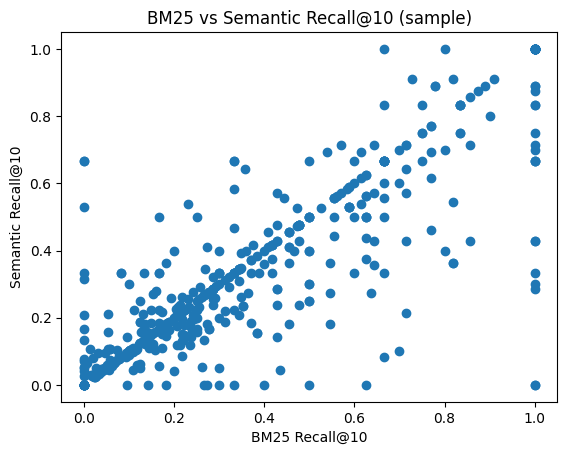

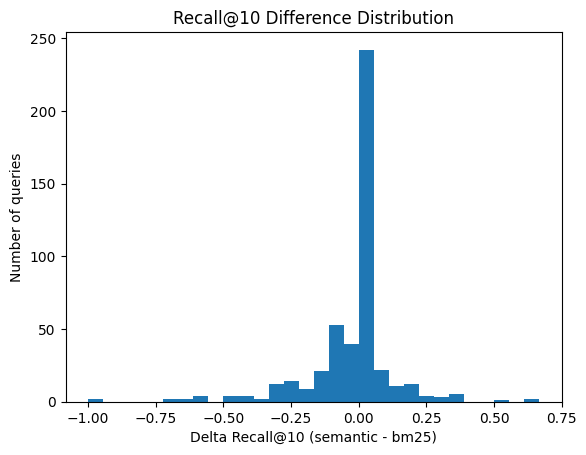

Semantic wins: 107
BM25 wins: 169
Ties: 195


,query_id,query,recall@10_bm25,recall@10_semantic,delta
13,13,outdoor privacy wall,0.000000,0.666667,0.666667
141,142,kitchen wooden stand,0.000000,0.666667,0.666667
227,235,bathroom wastebasket,0.000000,0.529412,0.529412
261,269,donaldson teak couch,0.166667,0.500000,0.333333
463,479,garage door mail slot,0.666667,1.000000,0.333333
182,185,lunch bag,0.333333,0.666667,0.333333
185,189,big basket for dirty cloths,0.333333,0.666667,0.333333
438,452,day bed indian,0.000000,0.333333,0.333333
236,244,pull out sleeper loveseat,0.000000,0.315789,0.315789
134,135,low profile loveseat recliner,0.230769,0.538462,0.307692


,query_id,query,recall@10_bm25,recall@10_semantic,delta
460,475,rattan truck,1.000000,0.000000,-1.000000
450,465,white abstract,1.000000,0.000000,-1.000000
304,313,malachi sled,1.000000,0.285714,-0.714286
359,372,verden callan,1.000000,0.300000,-0.700000
326,335,canadian,1.000000,0.333333,-0.666667
48,49,moen matte black hooks,0.625000,0.000000,-0.625000
159,161,accent chair recliner,0.700000,0.100000,-0.600000
383,396,alyse 8 light,0.666667,0.083333,-0.583333
273,281,brunk ship wheel,1.000000,0.428571,-0.571429
353,364,croscill ashton,1.000000,0.428571,-0.571429


In [30]:
# Visualize comparison
import matplotlib.pyplot as plt

comparison = bm25_recall.merge(
    sem_recall[["query_id", f"recall@{K}"]],
    on="query_id",
    suffixes=("_bm25", "_semantic")
)
comparison["delta"] = comparison[f"recall@{K}_semantic"] - comparison[f"recall@{K}_bm25"]

# Scatter plot
plt.figure()
plt.scatter(comparison[f"recall@{K}_bm25"], comparison[f"recall@{K}_semantic"])
plt.xlabel(f"BM25 Recall@{K}")
plt.ylabel(f"Semantic Recall@{K}")
plt.title(f"BM25 vs Semantic Recall@{K} (sample)")
plt.show()

# Histogram of deltas
plt.figure()
plt.hist(comparison["delta"], bins=30)
plt.xlabel(f"Delta Recall@{K} (semantic - bm25)")
plt.ylabel("Number of queries")
plt.title(f"Recall@{K} Difference Distribution")
plt.show()

print("Semantic wins:", (comparison["delta"] > 0).sum())
print("BM25 wins:", (comparison["delta"] < 0).sum())
print("Ties:", (comparison["delta"] == 0).sum())

display(comparison.sort_values("delta", ascending=False).head(10))
display(comparison.sort_values("delta", ascending=True).head(10))


---

## Task 5: Compare Embedding Models (20 points)

### 5a. Embed products with two different models (10 pts)

Compare embeddings from:
- `BAAI/bge-base-en-v1.5`
- `sentence-transformers/all-mpnet-base-v2`

In [31]:
# Load the two embedding models
from sentence_transformers import SentenceTransformer
import numpy as np
import time

model_bge = SentenceTransformer("BAAI/bge-base-en-v1.5")
model_mpnet = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

print("✅ Models loaded")


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2164.76it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2260.26it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Models loaded


In [32]:
# Embed products with both models
texts = products_sample["embed_text"].fillna("").astype(str).tolist()

print("Embedding with BGE...")
t0 = time.time()
emb_bge = model_bge.encode(texts, convert_to_numpy=True, show_progress_bar=True, batch_size=64)
print(f"✅ BGE done in {time.time() - t0:.1f}s | shape: {emb_bge.shape}")

print("Embedding with MPNet...")
t1 = time.time()
emb_mpnet = model_mpnet.encode(texts, convert_to_numpy=True, show_progress_bar=True, batch_size=64)
print(f"✅ MPNet done in {time.time() - t1:.1f}s | shape: {emb_mpnet.shape}")

print("BGE dim:", emb_bge.shape[1])
print("MPNet dim:", emb_mpnet.shape[1])


Embedding with BGE...


Batches: 100%|██████████| 79/79 [00:14<00:00,  5.27it/s]


✅ BGE done in 15.0s | shape: (5000, 768)
Embedding with MPNet...


Batches: 100%|██████████| 79/79 [00:19<00:00,  4.11it/s]

✅ MPNet done in 19.3s | shape: (5000, 768)
BGE dim: 768
MPNet dim: 768


In [33]:
import os
os.makedirs("temp", exist_ok=True)

np.save("temp/product_embeddings_bge.npy", emb_bge)
np.save("temp/product_embeddings_mpnet.npy", emb_mpnet)

print("✅ Saved embeddings to temp/")


✅ Saved embeddings to temp/


### 5b. Compare search results between models (10 pts)

Evaluate both models on the same queries and analyze differences.

In [34]:
print("Mean vector norm (BGE):", float(np.mean(np.linalg.norm(emb_bge, axis=1))))
print("Mean vector norm (MPNet):", float(np.mean(np.linalg.norm(emb_mpnet, axis=1))))


Mean vector norm (BGE): 1.0
Mean vector norm (MPNet): 1.0


In [35]:
def recall_at_k(retrieved_ids, relevant_ids, k=10):
    """
    Recall@k = (# relevant retrieved in top k) / (total # relevant)
    If there are no relevant docs, return np.nan (can't define recall).
    """
    if len(relevant_ids) == 0:
        return np.nan
    
    top_k = set(retrieved_ids[:k])
    return len(top_k.intersection(relevant_ids)) / len(relevant_ids)


Mean vector norm (BGE): 1.0
Mean vector norm (MPNet): 1.0
BGE mean Recall@10: 0.3515162751515954
MPNet mean Recall@10: 0.324715832239004
MPNet wins: 106
BGE wins: 152
Ties: 213

Top 10 MPNet improvements:


,query_id,query,recall@10_bge,recall@10_mpnet,delta
387,400,small ladies rocker swivel recliner,0.000000,0.666667,0.666667
382,395,pantry grey,0.000000,0.500000,0.500000
444,458,bubble guppies chair,0.000000,0.500000,0.500000
28,29,bathroom vanity knobs,0.117647,0.588235,0.470588
393,406,refrigerator with ice an water in door,0.666667,1.000000,0.333333
185,189,big basket for dirty cloths,0.333333,0.666667,0.333333
20,21,living curtains pearl,0.125000,0.437500,0.312500
134,135,low profile loveseat recliner,0.153846,0.461538,0.307692
154,156,papasan chair frame only,0.571429,0.857143,0.285714
273,281,brunk ship wheel,0.714286,1.000000,0.285714



Top 10 BGE improvements:


,query_id,query,recall@10_bge,recall@10_mpnet,delta
372,385,mom urn,1.000000,0.000000,-1.000000
172,174,star wars rug,1.000000,0.000000,-1.000000
469,486,54 in bench cushion,0.727273,0.000000,-0.727273
240,248,surge protector,1.000000,0.333333,-0.666667
300,309,moen 5995 arbor one,0.666667,0.000000,-0.666667
304,313,malachi sled,1.000000,0.428571,-0.571429
325,334,itchington butterfly,0.714286,0.142857,-0.571429
318,327,kohler purist brushed bronze,0.545455,0.000000,-0.545455
255,263,small curtain rods,0.642857,0.142857,-0.500000
192,197,desk for kids tjat ate 10 year old,0.833333,0.333333,-0.500000


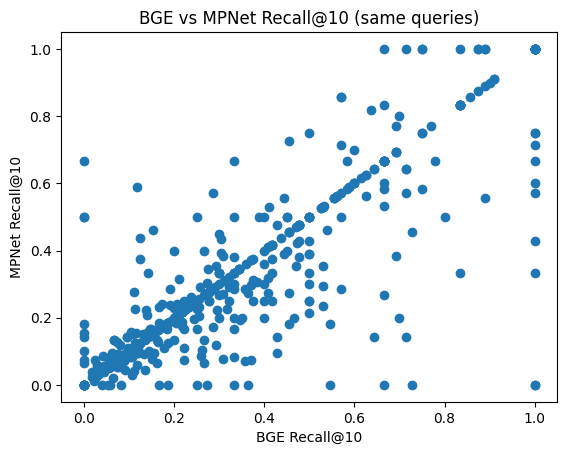


Query: comfortable sofa

BGE Top 5:


,rank,product_id,product_name,product_class,score
723,1,38543,sofa bed with ottoman,NaN,0.785501
2771,2,61,wimberley 76 '' pillow top arm reclining sofa,Sofas,0.768767
4800,3,6108,mccaffery 74 '' round arm sofa,NaN,0.766994
2736,4,27404,baeten patio sofa with cushions,NaN,0.766528
2120,5,9687,kendall sectional sofa with ottoman,Sectionals,0.766123



MPNet Top 5:


,rank,product_id,product_name,product_class,score
147,1,25617,phokas 93 '' square arm sofa,NaN,0.720043
250,2,41672,lucey patio sectional with cushions,Patio Sofas,0.714052
964,3,19565,aidann patio sectional with cushions,Patio Sofas,0.712630
289,4,22979,woodsen patio sectional with cushions,Patio Sofas,0.712420
2736,5,27404,baeten patio sofa with cushions,NaN,0.707859



Query: star wars rug

BGE Top 5:


...

,rank,product_id,product_name,product_class,score
1032,1,37296,novelty shayne patchwork cowhide leather gradient gray rug,Area Rugs,0.627657
1850,2,31495,matilda power loom red/beige rug,Area Rugs,0.613268
4992,3,26388,korn power loom burgundy/blue/gold rug,Area Rugs,0.609769
1017,4,16501,rugsotic carpets hand-knotted silk blue area rug,Area Rugs,0.608813
4368,5,13101,runner brandt oriental hand-knotted wool beige area rug,Area Rugs,0.601856



Query: modern coffee table

BGE Top 5:


,rank,product_id,product_name,product_class,score
2860,1,34711,coffee table with storage,NaN,0.837443
586,2,20479,florie solid coffee table,NaN,0.819132
695,3,6383,updegraff contemporary rect coffee table,Coffee & Cocktail Tables,0.813581
214,4,5434,wooden coffee table,Coffee & Cocktail Tables,0.802711
3754,5,608,coffee table,Coffee & Cocktail Tables,0.798713



MPNet Top 5:


,rank,product_id,product_name,product_class,score
695,1,6383,updegraff contemporary rect coffee table,Coffee & Cocktail Tables,0.846177
3754,2,608,coffee table,Coffee & Cocktail Tables,0.832651
3839,3,5205,choual coffee table,Coffee & Cocktail Tables,0.815955
1858,4,3510,ahern coffee table,Coffee & Cocktail Tables,0.796003
3053,5,31613,bettrys coffee table,Coffee & Cocktail Tables,0.793845


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Mean vector norm (requested)
print("Mean vector norm (BGE):", float(np.mean(np.linalg.norm(emb_bge, axis=1))))
print("Mean vector norm (MPNet):", float(np.mean(np.linalg.norm(emb_mpnet, axis=1))))


# 2) Cosine similarity search using a provided embedding matrix (from scratch)
def cosine_sim_matrix(query_vec: np.ndarray, doc_matrix: np.ndarray) -> np.ndarray:
    q_norm = np.linalg.norm(query_vec)
    d_norms = np.linalg.norm(doc_matrix, axis=1)
    denom = q_norm * d_norms
    denom = np.where(denom == 0, 1e-12, denom)
    return (doc_matrix @ query_vec) / denom


def semantic_search_with_model(query: str,
                               products_df: pd.DataFrame,
                               doc_embeddings: np.ndarray,
                               query_model,
                               k: int = 10) -> pd.DataFrame:
    q_vec = query_model.encode(query, convert_to_numpy=True)
    sims = cosine_sim_matrix(q_vec, doc_embeddings)
    top_k_idx = np.argsort(-sims)[:k]

    results = products_df.iloc[top_k_idx].copy()
    results["score"] = sims[top_k_idx]
    results["rank"] = range(1, k + 1)
    return results


# 3) Evaluate Recall@10 for each model on the same queries
def evaluate_recall_embeddings(queries_df: pd.DataFrame,
                               relevant_by_query: dict,
                               products_df: pd.DataFrame,
                               doc_embeddings: np.ndarray,
                               query_model,
                               k: int = 10) -> pd.DataFrame:
    rows = []
    for _, row in queries_df.iterrows():
        qid = int(row["query_id"])
        qtext = row["query"]

        relevant_set = relevant_by_query.get(qid, set())
        if len(relevant_set) == 0:
            continue

        res = semantic_search_with_model(
            query=qtext,
            products_df=products_df,
            doc_embeddings=doc_embeddings,
            query_model=query_model,
            k=k
        )
        retrieved_ids = res["product_id"].tolist()
        r = recall_at_k(retrieved_ids, relevant_set, k=k)

        rows.append({"query_id": qid, "query": qtext, f"recall@{k}": r})

    return pd.DataFrame(rows)


K = 10
bge_recall_df = evaluate_recall_embeddings(queries_eval, relevant_by_query, products_sample, emb_bge, model_bge, k=K)
mpnet_recall_df = evaluate_recall_embeddings(queries_eval, relevant_by_query, products_sample, emb_mpnet, model_mpnet, k=K)

print("BGE mean Recall@10:", bge_recall_df[f"recall@{K}"].mean())
print("MPNet mean Recall@10:", mpnet_recall_df[f"recall@{K}"].mean())


# 4) Merge results and analyze differences
comparison = bge_recall_df.merge(
    mpnet_recall_df[["query_id", f"recall@{K}"]],
    on="query_id",
    suffixes=("_bge", "_mpnet")
)
comparison["delta"] = comparison[f"recall@{K}_mpnet"] - comparison[f"recall@{K}_bge"]

print("MPNet wins:", int((comparison["delta"] > 0).sum()))
print("BGE wins:", int((comparison["delta"] < 0).sum()))
print("Ties:", int((comparison["delta"] == 0).sum()))

print("\nTop 10 MPNet improvements:")
display(comparison.sort_values("delta", ascending=False).head(10))

print("\nTop 10 BGE improvements:")
display(comparison.sort_values("delta", ascending=True).head(10))


# 5) Scatter plot: X-axis BGE Recall@10, Y-axis MPNet Recall@10
plt.figure()
plt.scatter(comparison[f"recall@{K}_bge"], comparison[f"recall@{K}_mpnet"])
plt.xlabel(f"BGE Recall@{K}")
plt.ylabel(f"MPNet Recall@{K}")
plt.title(f"BGE vs MPNet Recall@{K} (same queries)")
plt.show()


# 6) Compare results for specific queries (requested)
test_queries = ["comfortable sofa", "star wars rug", "modern coffee table"]  # add more!

for q in test_queries:
    print("\n" + "="*80)
    print("Query:", q)

    bge_res = semantic_search_with_model(q, products_sample, emb_bge, model_bge, k=10)
    mpnet_res = semantic_search_with_model(q, products_sample, emb_mpnet, model_mpnet, k=10)

    print("\nBGE Top 5:")
    display(bge_res[["rank", "product_id", "product_name", "product_class", "score"]].head(5))

    print("\nMPNet Top 5:")
    display(mpnet_res[["rank", "product_id", "product_name", "product_class", "score"]].head(5))


---

## Task 6: Git Submission (5 points)

Submit your work using the Git workflow:

- [ ] Create a new branch called `homework-4`
- [ ] Commit your work with a meaningful message
- [ ] Push to GitHub
- [ ] Create a Pull Request
- [ ] Merge the PR to main
- [ ] Submit the `.ipynb` file on Blackboard

The TA will verify your submission by checking the merged PR on GitHub.